<a href="https://www.kaggle.com/code/vladyslavtkachuk/notebookfc61a446ba?scriptVersionId=295132056" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:

import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [3]:
all_dataset = datasets.ImageFolder(data_dir)

In [4]:
all_dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [5]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

In [6]:
len(all_dataset)

16854

In [9]:
data_train, data_test = torch.utils.data.random_split(all_dataset,[0.8, 0.2])

In [10]:
print(len(data_train), len(data_test), len(data_train) + len(data_test))

13484 3370 16854


In [11]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]
        new_img = self.transformer(img)
        return new_img, y

In [12]:

train_data = TransformDataset(data_train,train_transform)
test_data = TransformDataset(data_test,test_transform)
print(len(train_data), len(test_data))

13484 3370


In [13]:

train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [14]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([42, 3, 224, 224])
torch.Size([42])


(224, 224, 3)


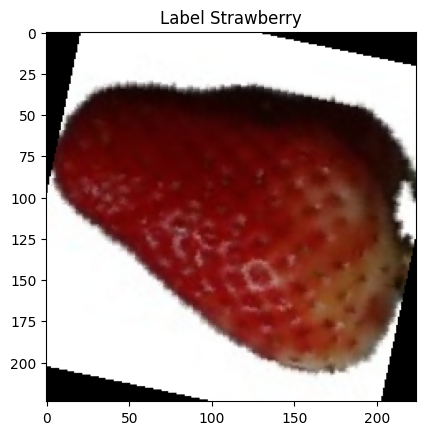

(224, 224, 3)


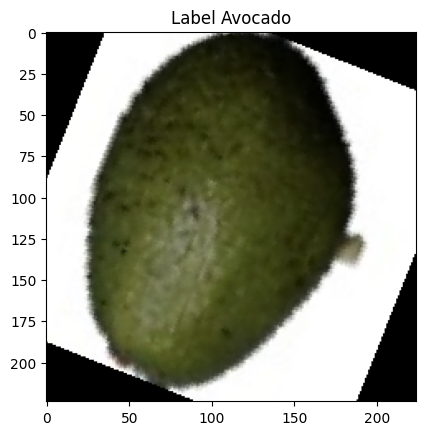

(224, 224, 3)


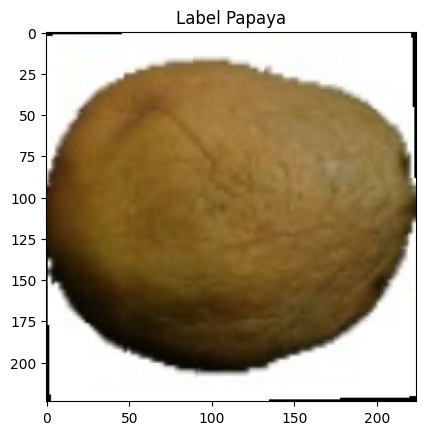

In [15]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = all_dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

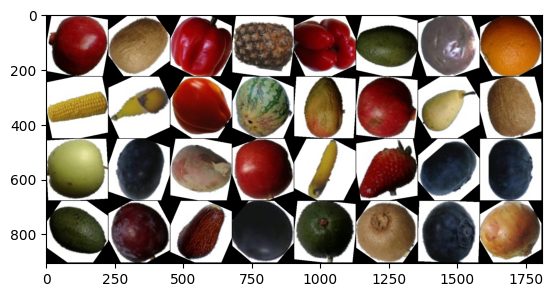

In [16]:
from torchvision.utils import make_grid
loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)
batch, labels = next(iter(loader))
grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор
plt.imshow(grid)